# NeuroVLM Quantitative Metrics

Evaluates both generative directions across three datasets.

| Direction | Datasets | Modes | Metrics |
|---|---|---|---|
| **Brain → Text** | Networks, PubMed, NeuroVault | Short (≈1 sentence) & Long (free-form) | BLEU-4, ROUGE-1/2/L |
| **Text → Brain** | Networks, PubMed, NeuroVault | — | Pearson *r*, PSNR, SSIM, Dice |

**Brain-to-Text generation modes**
- *Short*: LLM is instructed to output a single concise sentence.  
  For PubMed the LLM is asked to produce only the paper title; the generated title is compared against the real title.
- *Long*: No length instruction — the LLM generates a paragraph or two.  
  Compared against the full abstract (PubMed / NeuroVault) or the long network description (Networks).

**Corpus used for brain-image-to-term retrieval**  
n-grams extracted from ~30 k PubMed neuroimaging papers, weighted by cosine similarity to article
embeddings and ranked for each brain image by the concept classifier (`concept_clf.pt`).  
The top-k n-grams are the context fed to the LLM.

```
Prerequisites
pip install neurovlm[metrics,llm]
# Ollama (fast path):
ollama pull qwen2.5:3b-instruct
# HuggingFace path works offline — set LLM_BACKEND = "huggingface" below.
```

In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent, load_masker
from neurovlm.metrics import bleu, rouge, token_f1, pearson_correlation, psnr, compute_metrics

In [2]:
# ── LLM settings ──────────────────────────────────────────────────────────────
LLM_BACKEND = "ollama"              # "ollama" | "huggingface"
LLM_MODEL   = "qwen2.5:3b-instruct" # Ollama: any pulled model
                                     # HF: e.g. "Qwen/Qwen2.5-1.5B-Instruct"

# ── Evaluation budget ─────────────────────────────────────────────────────────
# Set to None to use the full dataset (very slow for B2T due to LLM calls).
MAX_B2T = 30   # samples per dataset for brain-to-text
MAX_T2B = 50   # samples per dataset for text-to-brain

# ── Retrieval settings ────────────────────────────────────────────────────────
B2T_TOP_K   = 5     # context rows passed to LLM
B2T_SIM_THR = 0.35  # cosine-similarity floor; relaxed if no rows pass

In [3]:
nvlm   = NeuroVLM()
masker = load_masker()

---
## Dataset Preparation

In [4]:
# ── Networks dataset ──────────────────────────────────────────────────────────
# Ground-truth descriptions for eight canonical resting-state networks
# from the Du et al. ICA atlas.
#
# Short GT (≈1 sentence): used for the *short* B2T mode.
# Long GT (rich description): used for the *long* B2T mode AND as the
#   text input for the T2B evaluation.

SHORT_LABELS = {
    "Language":               "Language network supporting speech comprehension and production.",
    "Auditory":               "Auditory network for acoustic processing and speech encoding.",
    "Default Mode":           "Default mode network for self-referential thought and memory retrieval.",
    "Frontoparietal Control": "Frontoparietal control network for executive function and working memory.",
    "Attention":              "Dorsal attention network for goal-directed visuospatial attention.",
    "Visual":                 "Visual network for feature processing and object recognition.",
    "Motor":                  "Sensorimotor network for movement planning, initiation, and execution.",
    "Cingulo-Opercular":      "Salience network detecting salient events and driving performance monitoring.",
}

LONG_LABELS = {
    "Language": (
        "Language network (LAN; perisylvian language network; frontotemporal language system) [SEP] "
        "Primary regions: left inferior frontal gyrus (Broca's complex), posterior superior/middle temporal gyrus, "
        "temporoparietal junction/angular gyrus. "
        "Function: speech/text comprehension and production—semantics, syntax, phonology, and sentence-level integration."
    ),
    "Auditory": (
        "Auditory network (AUD; auditory cortex network) [SEP] "
        "Primary regions: Heschl's gyrus (primary auditory cortex), planum temporale, superior temporal gyrus. "
        "Function: acoustic feature analysis (pitch/timbre/timing), auditory scene analysis, early speech-sound encoding, "
        "and detection of salient sounds."
    ),
    "Default Mode": (
        "Default mode network (DMN; default network; default state network) [SEP] "
        "Primary regions: medial prefrontal cortex, posterior cingulate/precuneus, angular gyrus (lateral parietal). "
        "Function: internally oriented cognition—autobiographical/episodic memory, self-referential thought, "
        "future simulation, social inference, and narrative/semantic integration."
    ),
    "Frontoparietal Control": (
        "Frontoparietal control network (FPCN; frontoparietal network/FPN; central executive network/CEN) [SEP] "
        "Primary regions: dorsolateral/rostrolateral prefrontal cortex (middle frontal), posterior parietal cortex "
        "(inferior parietal/around intraparietal sulcus). "
        "Function: goal maintenance and flexible executive control—working memory, rule implementation, planning, "
        "and rapid task switching."
    ),
    "Attention": (
        "Dorsal attention network [SEP] "
        "Primary regions: intraparietal sulcus/superior parietal lobule and frontal eye fields. "
        "Function: goal-directed, voluntary control of visuospatial attention."
    ),
    "Visual": (
        "Visual network (VIS; occipital visual network) [SEP] "
        "Primary regions: calcarine cortex/V1 (cuneus/lingual), extrastriate occipital cortex, "
        "ventral occipitotemporal visual areas. "
        "Function: visual feature processing (form/color/motion), object/scene representations, "
        "and visuospatial analysis."
    ),
    "Motor": (
        "Motor network (motor/sensorimotor network; SMN) [SEP] "
        "Primary regions: primary motor cortex (precentral gyrus), supplementary motor area, premotor cortex; "
        "with primary somatosensory cortex (postcentral gyrus) for sensorimotor integration. "
        "Function: movement planning, initiation, and execution, plus proprioceptive/tactile feedback "
        "used to control actions and maintain body-state representations."
    ),
    "Cingulo-Opercular": (
        "Salience network (SN; cingulo-opercular network/CON; midcingulo-insular network) [SEP] "
        "Primary regions: anterior insula/frontal operculum, dorsal anterior cingulate/medial frontal cortex. "
        "Function: detects behaviorally relevant internal/external events (including interoceptive/affective signals), "
        "prioritizes attention and arousal, and drives performance monitoring and control adjustments "
        "(error/conflict/uncertainty)."
    ),
}

# Map readable label → Du atlas network key
_LABEL_TO_DU = {
    "Language":               "LANG",
    "Auditory":               "AUD",
    "Default Mode":           "DN-A",
    "Frontoparietal Control": "FPN-A",
    "Attention":              "dATN-A",
    "Visual":                 "VIS-C",
    "Motor":                  "SMOT-A",
    "Cingulo-Opercular":      "CG-OP",
}

all_net_latents = load_latent("networks_neuro")
du = all_net_latents["Du"]

networks_data = {
    label: {
        "latent":   du[du_key],
        "short_gt": SHORT_LABELS[label],
        "long_gt":  LONG_LABELS[label],
    }
    for label, du_key in _LABEL_TO_DU.items()
    if du_key in du
}

print(f"Networks loaded: {list(networks_data.keys())}")

Networks loaded: ['Language', 'Auditory', 'Default Mode', 'Frontoparietal Control', 'Attention', 'Visual', 'Motor', 'Cingulo-Opercular']


In [5]:
# ── PubMed dataset ────────────────────────────────────────────────────────────
# Loads the publications DataFrame and filters to the held-out test split.
# Column names: pmid, name (title), description (abstract), split.

df_pubs = load_dataset("pubmed_text")
print("PubMed columns:", df_pubs.columns.tolist())
print(f"Total rows: {len(df_pubs)}")

if "split" in df_pubs.columns:
    df_test = df_pubs[df_pubs["split"] == "test"].reset_index(drop=True)
    print(f"Test split rows: {len(df_test)}")
else:
    print("WARNING: no 'split' column found — using full dataset as test proxy.")
    df_test = df_pubs.copy().reset_index(drop=True)

# Detect column names defensively
_pmid_col     = "pmid"        if "pmid"        in df_test.columns else df_test.columns[0]
_title_col    = "name"        if "name"        in df_test.columns else "title"
_abstract_col = "description" if "description" in df_test.columns else "abstract"

# Load pre-encoded pubmed image latents and align to test rows
pubmed_latents, pubmed_pmids = load_latent("pubmed_images")
pubmed_pmids = np.asarray(pubmed_pmids)

mask = np.isin(pubmed_pmids, df_test[_pmid_col].values)
aligned_latents = pubmed_latents[mask]
aligned_pmids   = pubmed_pmids[mask]

pmid_to_row = df_test.set_index(_pmid_col)

pubmed_data = []
for i, pmid in enumerate(aligned_pmids):
    if pmid not in pmid_to_row.index:
        continue
    row      = pmid_to_row.loc[pmid]
    title    = str(row[_title_col])    if _title_col    in row.index else ""
    abstract = str(row[_abstract_col]) if _abstract_col in row.index else ""
    pubmed_data.append({
        "pmid":     pmid,
        "latent":   aligned_latents[i],
        "short_gt": title,       # Short GT = paper title
        "long_gt":  abstract,    # Long GT  = abstract
    })

# Cap for evaluation budget
if MAX_B2T is not None:
    pubmed_data_b2t = pubmed_data[:MAX_B2T]
else:
    pubmed_data_b2t = pubmed_data

if MAX_T2B is not None:
    pubmed_data_t2b = pubmed_data[:MAX_T2B]
else:
    pubmed_data_t2b = pubmed_data

print(f"PubMed B2T samples: {len(pubmed_data_b2t)}")
print(f"PubMed T2B samples: {len(pubmed_data_t2b)}")

PubMed columns: ['pmid', 'pmcid', 'doi', 'name', 'description', 'train', 'test', 'val']
Total rows: 30826
PubMed B2T samples: 30
PubMed T2B samples: 50


In [6]:
# ── NeuroVault dataset ────────────────────────────────────────────────────────
# Each row in df_nv is a publication (doi, title, abstract).
# df_nv_meta maps each image index → publication doi.
# For each publication we select one representative brain image.

df_nv      = load_dataset("neurovault_text")        # publications: doi, title, abstract
df_nv_meta = load_dataset("neurovault_images_meta") # image-level metadata
nv_latents = load_latent("neurovault_images")        # encoded image latents

print("NeuroVault pub columns:",   df_nv.columns.tolist())
print("NeuroVault meta columns:",  df_nv_meta.columns.tolist())
print(f"NV latents shape: {nv_latents.shape}")

# Detect column names
_doi_pub  = "doi"      if "doi"      in df_nv.columns      else df_nv.columns[0]
_doi_meta = "doi"      if "doi"      in df_nv_meta.columns else df_nv_meta.columns[0]
_title_nv = "title"    if "title"    in df_nv.columns      else df_nv.columns[1]
_abs_nv   = "abstract" if "abstract" in df_nv.columns      else df_nv.columns[2]

neurovault_data = []
for _, pub_row in df_nv.iterrows():
    doi      = pub_row[_doi_pub]
    title    = str(pub_row[_title_nv])
    abstract = str(pub_row[_abs_nv])

    # Find image(s) belonging to this publication
    img_mask    = df_nv_meta[_doi_meta] == doi
    img_indices = np.where(img_mask.values)[0]

    if len(img_indices) == 0 or img_indices[0] >= len(nv_latents):
        continue

    # Take the first image as the representative latent.
    # (For a more rigorous approach, select the image whose latent is most
    #  similar to the text latent — see notebook 12.)
    img_idx = int(img_indices[0])

    neurovault_data.append({
        "doi":      doi,
        "latent":   nv_latents[img_idx],
        "short_gt": title,
        "long_gt":  abstract,
    })

if MAX_B2T is not None:
    neurovault_data_b2t = neurovault_data[:MAX_B2T]
else:
    neurovault_data_b2t = neurovault_data

if MAX_T2B is not None:
    neurovault_data_t2b = neurovault_data[:MAX_T2B]
else:
    neurovault_data_t2b = neurovault_data

print(f"NeuroVault B2T samples: {len(neurovault_data_b2t)}")
print(f"NeuroVault T2B samples: {len(neurovault_data_t2b)}")

NeuroVault pub columns: ['doi', 'title', 'abstract']
NeuroVault meta columns: ['Unnamed: 0', 'id', 'collection_id', 'contrast_definition', 'name', 'doi']
NV latents shape: torch.Size([3183, 384])
NeuroVault B2T samples: 30
NeuroVault T2B samples: 50


---
## Part A — Brain-to-Text (BLEU & ROUGE)

For each brain image we:
1. Retrieve the most similar text entries via contrastive similarity.
2. Generate with the LLM twice — once in **short** mode, once in **long** mode.
3. Compute BLEU-4 and ROUGE-1/2/L against the respective ground-truth.

**Short mode** — single sentence output:  
- Networks / NeuroVault: scored against the one-sentence label.  
- PubMed: LLM instructed to generate **only the title**; scored against the actual title.

**Long mode** — free-form output (no length instruction):  
- Networks: scored against the full network description.  
- PubMed / NeuroVault: scored against the full abstract.

In [7]:
import traceback

def _b2t_once(table, user_prompt, gt_text, max_tokens):
    """Generate one B2T response and compute BLEU/ROUGE/token-F1 against gt_text."""
    generated = nvlm.generate_llm_response(
        backend=LLM_BACKEND,
        model_name=LLM_MODEL,
        table=table,
        user_prompt=user_prompt,
        max_new_tokens=max_tokens,
        verbose=False,
    )
    b = bleu([gt_text], generated, n=4)
    r = rouge(gt_text, generated)
    tf1 = token_f1(gt_text, generated)
    return {
        "generated": generated,
        "gt_text":   gt_text,
        "bleu":      b,
        "token_f1":  tf1,
        "rouge1_f":  r["rouge1"]["fmeasure"],
        "rouge2_f":  r["rouge2"]["fmeasure"],
        "rougeL_f":  r["rougeL"]["fmeasure"],
        "rouge1_p":  r["rouge1"]["precision"],
        "rouge1_r":  r["rouge1"]["recall"],
    }


def _format_context_summary(table):
    """Format retrieved context rows as a compact readable string."""
    lines = []
    for _, row in table.iterrows():
        ds  = row.get("dataset", "?")
        ttl = str(row.get("title", "")).strip()
        sim = row.get("cosine_similarity", float("nan"))
        lines.append(f"  [{ds}] (sim={sim:.3f}) {ttl}")
    return "\n".join(lines)


def run_b2t(name, latent, short_gt, long_gt,
            short_prompt, long_prompt="",
            short_tokens=64, long_tokens=512):
    """
    Run both short and long B2T evaluation for one sample.

    Returns a list of two record dicts (short + long), or [] on error.
    """
    try:
        result = nvlm.brain(latent).to_text()
        table  = result.top_k(B2T_TOP_K).query(f"cosine_similarity > {B2T_SIM_THR}")
        if table.empty:
            table = result.top_k(B2T_TOP_K)

        context_summary = _format_context_summary(table)

        records = []
        for mode, prompt, gt, tokens in [
            ("short", short_prompt, short_gt, short_tokens),
            ("long",  long_prompt,  long_gt,  long_tokens),
        ]:
            rec = _b2t_once(table, prompt, gt, tokens)
            rec["name"]            = name
            rec["mode"]            = mode
            rec["context_summary"] = context_summary
            records.append(rec)

        return records

    except Exception as e:
        print(f"\n[B2T error] {name}: {type(e).__name__}: {e}")
        traceback.print_exc()
        return []


def show_b2t_texts(df, max_gt_chars=300, max_gen_chars=300):
    """Print retrieved context + generated vs expected text for each row."""
    sep = "-" * 72
    prev_name = None
    for _, row in df.iterrows():
        name    = row.get("name", "?")
        mode    = row.get("mode", "?")
        gen     = str(row.get("generated",       "")).strip()
        gt      = str(row.get("gt_text",         "")).strip()
        ctx     = str(row.get("context_summary", "")).strip()
        b       = row.get("bleu",     float("nan"))
        tf1     = row.get("token_f1", float("nan"))
        r1      = row.get("rouge1_f", float("nan"))

        print(sep)
        # Only print the context once per sample (shared by short + long)
        if name != prev_name and ctx:
            print(f"[{name}]  — retrieved context:")
            print(ctx)
            prev_name = name

        print(f"  mode={mode}   BLEU={b:.3f}  token-F1={tf1:.3f}  ROUGE-1={r1:.3f}")
        print(f"  EXPECTED : {gt[:max_gt_chars]}{'…' if len(gt) > max_gt_chars else ''}")
        print(f"  GENERATED: {gen[:max_gen_chars]}{'…' if len(gen) > max_gen_chars else ''}")
    print(sep)


# ── Prompts ────────────────────────────────────────────────────────────────────
SHORT_PROMPT_GENERAL = (
    "Reply with a single concise sentence (10-20 words) naming the main "
    "cognitive function or brain network. Output only that sentence."
)

SHORT_PROMPT_PUBMED = (
    "Generate ONLY a paper title (6-12 words) for the neuroimaging study this "
    "brain activation pattern represents. Output the title only — no abstract, "
    "no explanation."
)

LONG_PROMPT = ""

### A.1 Networks

In [8]:
b2t_networks_records = []

for net_name, d in tqdm(networks_data.items(), desc="Networks B2T"):
    recs = run_b2t(
        name         = net_name,
        latent       = d["latent"],
        short_gt     = d["short_gt"],
        long_gt      = d["long_gt"],
        short_prompt = SHORT_PROMPT_GENERAL,
        long_prompt  = LONG_PROMPT,
    )
    b2t_networks_records.extend(recs)

print(f"\nRecords collected: {len(b2t_networks_records)}")

b2t_net_df = pd.DataFrame(b2t_networks_records)

if b2t_net_df.empty:
    print("No records — check the [B2T error] messages above for the root cause.")
else:
    cols = ["name", "mode", "bleu", "token_f1", "rouge1_f", "rouge2_f", "rougeL_f"]
    display(b2t_net_df[cols].round(3))
    print()
    show_b2t_texts(b2t_net_df)

Networks B2T:   0%|          | 0/8 [00:00<?, ?it/s]


Records collected: 16


,name,mode,bleu,token_f1,rouge1_f,rouge2_f,rougeL_f
0,Language,short,0.021,0.118,0.118,0.000,0.118
1,Language,long,0.001,0.027,0.071,0.009,0.062
2,Auditory,short,0.024,0.118,0.118,0.000,0.118
3,Auditory,long,0.001,0.037,0.070,0.016,0.051
4,Default Mode,short,0.138,0.588,0.842,0.706,0.842
5,Default Mode,long,0.004,0.066,0.148,0.048,0.112
6,Frontoparietal Control,short,0.029,0.222,0.222,0.000,0.222
7,Frontoparietal Control,long,0.001,0.039,0.062,0.014,0.044
8,Attention,short,0.021,0.118,0.111,0.000,0.111
9,Attention,long,0.001,0.045,0.080,0.009,0.071



------------------------------------------------------------------------
[Language]  — retrieved context:
[cogatlas] (sim=0.385) emotional expression
  [cogatlas] (sim=0.380) narrative comprehension
  [cogatlas] (sim=0.375) sentence comprehension
  [cogatlas] (sim=0.369) language processing
  [cogatlas] (sim=0.365) empathy
  [ngrams] (sim=0.407) fluent
  [ngrams] (sim=0.402) speech acts
  [ngrams] (sim=0.377) story
  [ngrams] (sim=0.359) spoken written
  [ngrams] (sim=0.355) acts
  [wiki] (sim=0.443) Nonverbal autism
  [wiki] (sim=0.438) Stance (linguistics)
  [wiki] (sim=0.433) Phatic expression
  [wiki] (sim=0.433) Emotional prosody
  [wiki] (sim=0.429) Verbal Behavior
  mode=short   BLEU=0.021  token-F1=0.118  ROUGE-1=0.118
  EXPECTED : Language network supporting speech comprehension and production.
  GENERATED: Emotional prosody and empathetic responses underpin fluency in verbal behavior.
------------------------------------------------------------------------
  mode=long   BLEU

### A.2 PubMed

*Short* → LLM generates a title, evaluated against the real title.  
*Long* → LLM generates freely, evaluated against the abstract.

In [9]:
b2t_pubmed_records = []

for d in tqdm(pubmed_data_b2t, desc="PubMed B2T"):
    recs = run_b2t(
        name         = str(d["pmid"]),
        latent       = d["latent"],
        short_gt     = d["short_gt"],   # title
        long_gt      = d["long_gt"],    # abstract
        short_prompt = SHORT_PROMPT_PUBMED,
        long_prompt  = LONG_PROMPT,
        short_tokens = 48,
        long_tokens  = 512,
    )
    b2t_pubmed_records.extend(recs)

print(f"\nRecords collected: {len(b2t_pubmed_records)}")

b2t_pubmed_df = pd.DataFrame(b2t_pubmed_records)

if b2t_pubmed_df.empty:
    print("No records — check the [B2T error] messages above for the root cause.")
else:
    display(b2t_pubmed_df.groupby("mode")[["bleu", "token_f1", "rouge1_f", "rouge2_f", "rougeL_f"]].mean().round(3))
    print()
    show_b2t_texts(b2t_pubmed_df)

PubMed B2T:   0%|          | 0/30 [00:00<?, ?it/s]


Records collected: 60


,bleu,token_f1,rouge1_f,rouge2_f,rougeL_f
mode,,,,,
long,0.004,0.182,0.213,0.021,0.109
short,0.008,0.073,0.087,0.011,0.072



------------------------------------------------------------------------
[1589767]  — retrieved context:
[cogatlas] (sim=0.479) word pronunciation
  [cogatlas] (sim=0.467) language processing
  [cogatlas] (sim=0.448) phonological processing
  [cogatlas] (sim=0.447) speech production
  [cogatlas] (sim=0.443) speech perception
  [ngrams] (sim=0.500) analysis corpus
  [ngrams] (sim=0.455) left vot
  [ngrams] (sim=0.452) language lateralisation
  [ngrams] (sim=0.439) speech acts
  [ngrams] (sim=0.437) spoken language
  [wiki] (sim=0.489) Diachrony and synchrony
  [wiki] (sim=0.486) Chroneme
  [wiki] (sim=0.485) Alternation (linguistics)
  [wiki] (sim=0.484) Syntagma (linguistics)
  [wiki] (sim=0.481) Diaphoneme
  mode=short   BLEU=0.000  token-F1=0.000  ROUGE-1=0.000
  EXPECTED : Lateralization of phonetic and pitch discrimination in speech processing.
  GENERATED: Diachrony Synchrony Linguistic Patterns Analysis
------------------------------------------------------------------------
  m

### A.3 NeuroVault

In [10]:
b2t_nv_records = []

for d in tqdm(neurovault_data_b2t, desc="NeuroVault B2T"):
    recs = run_b2t(
        name         = str(d["doi"]),
        latent       = d["latent"],
        short_gt     = d["short_gt"],   # title
        long_gt      = d["long_gt"],    # abstract
        short_prompt = SHORT_PROMPT_GENERAL,
        long_prompt  = LONG_PROMPT,
    )
    b2t_nv_records.extend(recs)

print(f"\nRecords collected: {len(b2t_nv_records)}")

b2t_nv_df = pd.DataFrame(b2t_nv_records)

if b2t_nv_df.empty:
    print("No records — check the [B2T error] messages above for the root cause.")
else:
    display(b2t_nv_df.groupby("mode")[["bleu", "token_f1", "rouge1_f", "rouge2_f", "rougeL_f"]].mean().round(3))
    print()
    show_b2t_texts(b2t_nv_df)

NeuroVault B2T:   0%|          | 0/30 [00:00<?, ?it/s]


Records collected: 60


,bleu,token_f1,rouge1_f,rouge2_f,rougeL_f
mode,,,,,
long,0.004,0.178,0.212,0.017,0.102
short,0.007,0.044,0.053,0.003,0.040



------------------------------------------------------------------------
[10.1111/cdev.12630]  — retrieved context:
[ngrams] (sim=0.372) mood
  [wiki] (sim=0.393) Favorinus
  [wiki] (sim=0.387) Body reactivity
  [wiki] (sim=0.385) Mind–body dualism
  [wiki] (sim=0.385) Soul dualism
  [wiki] (sim=0.385) Racism
  mode=short   BLEU=0.024  token-F1=0.154  ROUGE-1=0.154
  EXPECTED : Neural Reactivity to Emotional Faces May Mediate the Relationship Between Childhood Empathy and Adolescent Prosocial Behavior
  GENERATED: Favorinus links body reactivity to soul dualism impacting mood disorders.
------------------------------------------------------------------------
  mode=long   BLEU=0.003  token-F1=0.167  ROUGE-1=0.188
  EXPECTED : Reactivity to others' emotions not only can result in empathic concern (EC), an important motivator of prosocial behavior, but can also result in personal distress (PD), which may hinder prosocial behavior. Examining neural substrates of emotional reactivity may 

### A.4 Brain-to-Text Summary

In [11]:
# Tag each DataFrame with its dataset source
b2t_net_df["dataset"]    = "networks"
b2t_pubmed_df["dataset"] = "pubmed"
b2t_nv_df["dataset"]     = "neurovault"

b2t_all = pd.concat([b2t_net_df, b2t_pubmed_df, b2t_nv_df], ignore_index=True)

summary_b2t = (
    b2t_all
    .groupby(["dataset", "mode"])[["bleu", "token_f1", "rouge1_f", "rouge2_f", "rougeL_f"]]
    .agg(["mean", "std"])
    .round(3)
)

print("=== Brain-to-Text Summary (mean ± std) ===")
summary_b2t

=== Brain-to-Text Summary (mean ± std) ===


bleu        token_f1        rouge1_f        rouge2_f  \
                   mean    std     mean    std     mean    std     mean   
dataset    mode                                                           
networks   long   0.002  0.002    0.052  0.024    0.103  0.043    0.019   
           short  0.039  0.040    0.220  0.159    0.281  0.250    0.088   
neurovault long   0.004  0.003    0.178  0.048    0.212  0.057    0.017   
           short  0.007  0.009    0.044  0.061    0.053  0.071    0.003   
pubmed     long   0.004  0.004    0.182  0.049    0.213  0.058    0.021   
           short  0.008  0.011    0.073  0.098    0.087  0.110    0.011   

                        rougeL_f         
                    std     mean    std  
dataset    mode                          
networks   long   0.016    0.075  0.025  
           short  0.250    0.251  0.246  
neurovault long   0.011    0.102  0.022  
           short  0.015    0.040  0.053  
pubmed     long   0.016    0.109  0.027  
           short  0.034    0.072  0.088

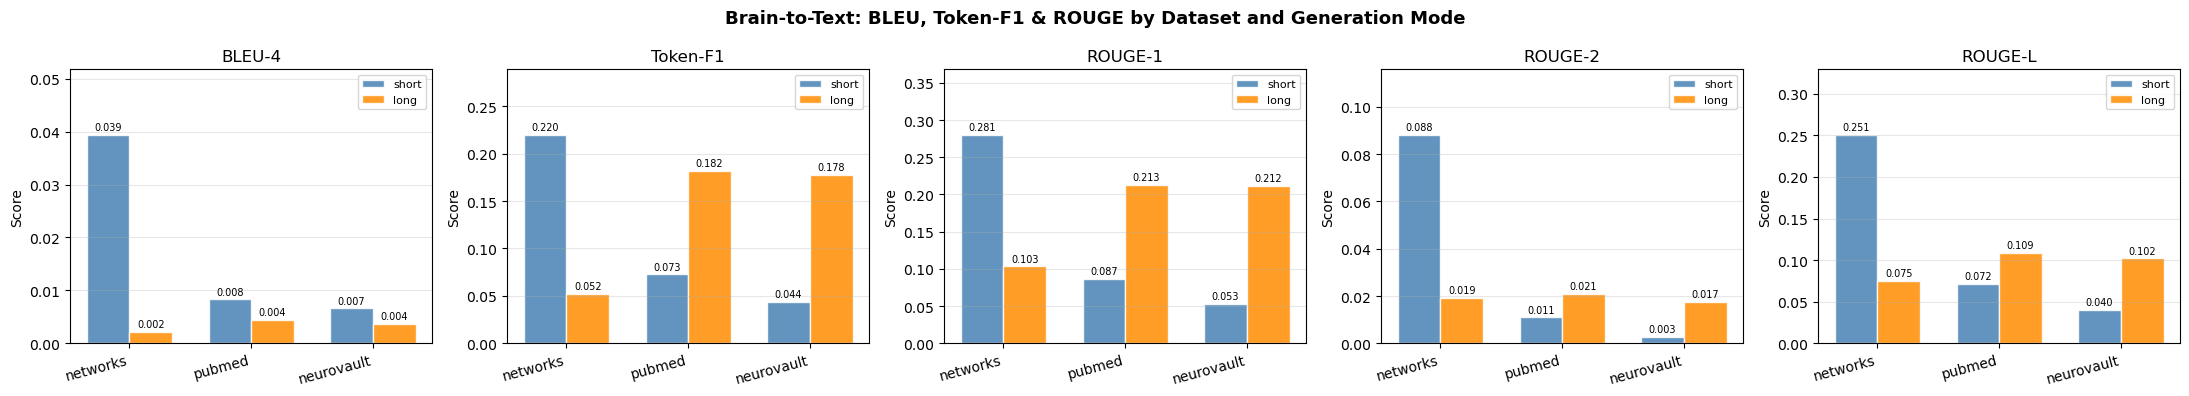

In [12]:
datasets  = ["networks", "pubmed", "neurovault"]
modes     = ["short", "long"]
metrics   = ["bleu", "token_f1", "rouge1_f", "rouge2_f", "rougeL_f"]
m_labels  = ["BLEU-4", "Token-F1", "ROUGE-1", "ROUGE-2", "ROUGE-L"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)
x      = np.arange(len(datasets))
w      = 0.35
colors = {"short": "steelblue", "long": "darkorange"}

for ax, metric, m_label in zip(axes, metrics, m_labels):
    for j, mode in enumerate(modes):
        vals = [
            b2t_all[(b2t_all["dataset"] == ds) & (b2t_all["mode"] == mode)][metric].mean()
            for ds in datasets
        ]
        offset = (j - 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=mode,
                      color=colors[mode], alpha=0.85, edgecolor="white")
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=15, ha="right")
    ax.set_title(m_label)
    ax.set_ylabel("Score")
    ax.set_ylim(0, max(0.05, ax.get_ylim()[1] * 1.25))
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Brain-to-Text: BLEU, Token-F1 & ROUGE by Dataset and Generation Mode",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("b2t_metrics_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

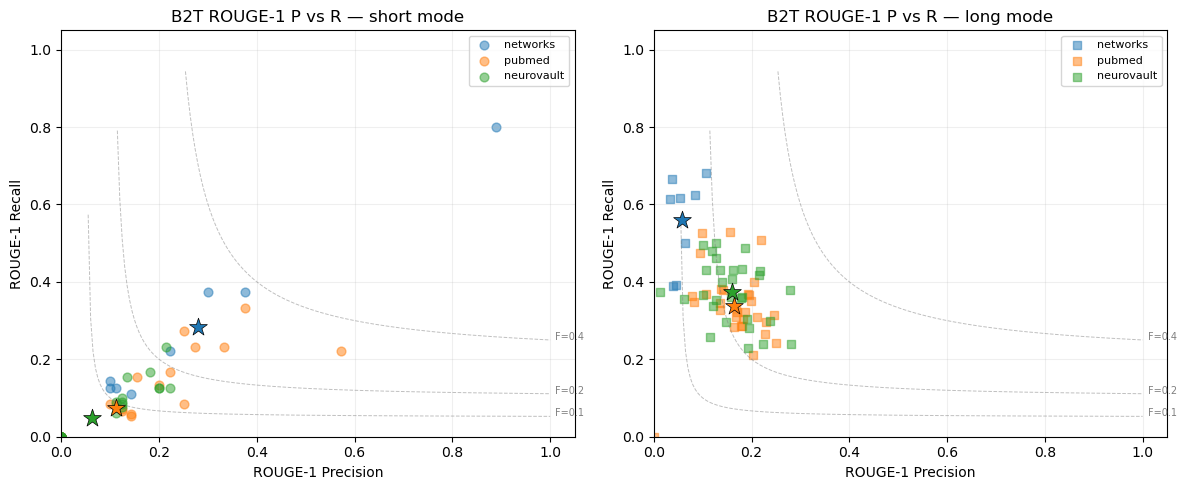

In [13]:
# ROUGE-1 Precision vs Recall scatter (one point per dataset × mode)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ds_colors = {"networks": "C0", "pubmed": "C1", "neurovault": "C2"}
ds_markers = {"short": "o", "long": "s"}

p_range = np.linspace(0.01, 1.0, 200)
for ax, mode in zip(axes, modes):
    sub = b2t_all[b2t_all["mode"] == mode]
    for ds in datasets:
        rows = sub[sub["dataset"] == ds]
        ax.scatter(rows["rouge1_p"], rows["rouge1_r"],
                   s=40, alpha=0.5, color=ds_colors[ds], label=ds,
                   marker=ds_markers[mode])
        # Mark mean
        ax.scatter(rows["rouge1_p"].mean(), rows["rouge1_r"].mean(),
                   s=180, color=ds_colors[ds], marker="*", zorder=5,
                   edgecolors="black", linewidths=0.5)

    for f in [0.1, 0.2, 0.4]:
        r_iso = f * p_range / (2 * p_range - f + 1e-9)
        mask  = (r_iso >= 0) & (r_iso <= 1)
        ax.plot(p_range[mask], r_iso[mask], "--", lw=0.7, color="grey", alpha=0.5)
        ax.text(p_range[mask][-1] + 0.01, r_iso[mask][-1], f"F={f}",
                fontsize=7, color="grey")

    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.set_xlabel("ROUGE-1 Precision")
    ax.set_ylabel("ROUGE-1 Recall")
    ax.set_title(f"B2T ROUGE-1 P vs R — {mode} mode")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.tight_layout()
plt.savefig("b2t_rouge1_pr.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part B — Text-to-Brain (Pearson *r*, PSNR, SSIM, Dice)

For each text input we:
1. Generate a predicted brain activation map via `nvlm.text(input).to_brain(head="mse")`.
2. Decode the ground-truth latent through the same autoencoder decoder.
3. Compare the two maps with spatial metrics.

No short/long split for this direction — input text is always the full label/abstract.

In [14]:
def run_t2b(name, text_input, true_latent):
    """
    Text-to-brain evaluation for one sample.

    Parameters
    ----------
    name        : label used in results
    text_input  : string fed to nvlm.text()
    true_latent : autoencoder encoder output (1-D or 2-D tensor) for the
                  ground-truth brain map

    Returns
    -------
    dict of metric values, or None on error
    """
    try:
        # --- Generate predicted brain map ---------------------------------
        gen_result  = nvlm.text(text_input).to_brain(head="mse")
        nifti_pred  = gen_result.to_nifti(index=0)
        brain_pred  = masker.transform(nifti_pred).ravel().astype("float32")

        # --- Ground-truth map via same decoder ----------------------------
        dec        = gen_result.decoder
        dec_device = next(dec.parameters()).device
        lat        = true_latent
        if lat.dim() == 1:
            lat = lat.unsqueeze(0)
        with torch.no_grad():
            brain_true = (
                torch.sigmoid(dec(lat.to(dec_device)))
                .squeeze(0).cpu().numpy()
            )

        # --- Metrics ------------------------------------------------------
        r = pearson_correlation(brain_true, brain_pred)
        p = psnr(brain_true, brain_pred, data_range=1.0)
        mse_t, ssim_t, dice_t = compute_metrics(
            torch.from_numpy(brain_true),
            torch.from_numpy(brain_pred),
            thresholds=(0.25, 0.5),
            percentile=False,
        )

        return {
            "name":       name,
            "text_input": text_input[:80],
            "pearson_r":  float(r),
            "psnr_db":    float(p),
            "ssim_t025":  float(ssim_t[0]),
            "ssim_t050":  float(ssim_t[1]),
            "dice_t025":  float(dice_t[0]),
            "dice_t050":  float(dice_t[1]),
        }

    except Exception as e:
        print(f"  [T2B error] {name}: {e}")
        return None

### B.1 Networks

Text input = long network description.  
Ground truth = Du atlas network latent.

In [15]:
t2b_networks_records = []

for net_name, d in tqdm(networks_data.items(), desc="Networks T2B"):
    rec = run_t2b(
        name        = net_name,
        text_input  = d["long_gt"],
        true_latent = d["latent"],
    )
    if rec is not None:
        t2b_networks_records.append(rec)

t2b_net_df = pd.DataFrame(t2b_networks_records).set_index("name")

display_cols = ["pearson_r", "psnr_db", "ssim_t025", "ssim_t050", "dice_t025", "dice_t050"]
t2b_net_df[display_cols].round(3)

Networks T2B:   0%|          | 0/8 [00:00<?, ?it/s]

,pearson_r,psnr_db,ssim_t025,ssim_t050,dice_t025,dice_t050
name,,,,,,
Language,0.537,20.010,0.907,0.942,0.101,0.000
Auditory,0.646,24.931,0.969,0.972,0.576,0.000
Default Mode,0.499,21.839,0.926,0.959,0.098,0.000
Frontoparietal Control,0.580,23.030,0.918,0.965,0.000,0.000
Attention,0.433,21.584,0.926,0.962,0.000,0.000
Visual,0.461,20.545,0.958,0.972,0.063,0.000
Motor,0.553,20.619,0.930,0.953,0.415,0.038
Cingulo-Opercular,0.359,20.024,0.924,0.954,0.003,0.000


### B.2 PubMed

Text input = title + " [SEP] " + abstract.  
Ground truth = pre-encoded PubMed brain image latent (test split).

In [16]:
t2b_pubmed_records = []

for d in tqdm(pubmed_data_t2b, desc="PubMed T2B"):
    text_in = d["short_gt"] + " [SEP] " + d["long_gt"]
    rec = run_t2b(
        name        = str(d["pmid"]),
        text_input  = text_in,
        true_latent = d["latent"],
    )
    if rec is not None:
        t2b_pubmed_records.append(rec)

t2b_pubmed_df = pd.DataFrame(t2b_pubmed_records)

print(f"PubMed T2B — {len(t2b_pubmed_df)} samples evaluated")
t2b_pubmed_df[["pearson_r", "psnr_db", "ssim_t025", "dice_t025"]].describe().round(3)

PubMed T2B:   0%|          | 0/50 [00:00<?, ?it/s]

PubMed T2B — 50 samples evaluated


,pearson_r,psnr_db,ssim_t025,dice_t025
count,50.000,50.000,50.000,50.000
mean,0.393,26.903,0.964,0.022
std,0.192,2.784,0.029,0.142
min,-0.046,20.636,0.885,0.000
25%,0.261,25.680,0.955,0.000
50%,0.405,27.236,0.974,0.000
75%,0.549,28.845,0.983,0.000
max,0.713,32.049,1.000,1.000


### B.3 NeuroVault

Text input = title + " [SEP] " + abstract.  
Ground truth = pre-encoded NeuroVault brain image latent.

In [17]:
t2b_nv_records = []

for d in tqdm(neurovault_data_t2b, desc="NeuroVault T2B"):
    text_in = d["short_gt"] + " [SEP] " + d["long_gt"]
    rec = run_t2b(
        name        = str(d["doi"]),
        text_input  = text_in,
        true_latent = d["latent"],
    )
    if rec is not None:
        t2b_nv_records.append(rec)

t2b_nv_df = pd.DataFrame(t2b_nv_records)

print(f"NeuroVault T2B — {len(t2b_nv_df)} samples evaluated")
t2b_nv_df[["pearson_r", "psnr_db", "ssim_t025", "dice_t025"]].describe().round(3)

NeuroVault T2B:   0%|          | 0/50 [00:00<?, ?it/s]

NeuroVault T2B — 50 samples evaluated


,pearson_r,psnr_db,ssim_t025,dice_t025
count,50.000,50.000,50.000,50.0
mean,0.152,22.799,0.946,0.0
std,0.161,3.371,0.024,0.0
min,-0.096,16.462,0.876,0.0
25%,0.032,20.129,0.934,0.0
50%,0.131,22.003,0.944,0.0
75%,0.250,24.883,0.959,0.0
max,0.517,32.047,0.997,0.0


### B.4 Text-to-Brain Summary

In [18]:
t2b_net_df_flat    = t2b_net_df.reset_index().rename(columns={"name": "sample"})
t2b_net_df_flat["dataset"]    = "networks"
t2b_pubmed_df["dataset"]      = "pubmed"
t2b_nv_df["dataset"]          = "neurovault"

t2b_all = pd.concat(
    [t2b_net_df_flat, t2b_pubmed_df, t2b_nv_df],
    ignore_index=True
)

t2b_metric_cols = ["pearson_r", "psnr_db", "ssim_t025", "ssim_t050",
                   "dice_t025", "dice_t050"]

summary_t2b = (
    t2b_all
    .groupby("dataset")[t2b_metric_cols]
    .agg(["mean", "std"])
    .round(3)
)

print("=== Text-to-Brain Summary (mean ± std) ===")
summary_t2b

=== Text-to-Brain Summary (mean ± std) ===


pearson_r        psnr_db        ssim_t025        ssim_t050         \
                mean    std    mean    std      mean    std      mean    std   
dataset                                                                        
networks       0.508  0.090  21.573  1.702     0.932  0.021     0.960  0.010   
neurovault     0.152  0.161  22.799  3.371     0.946  0.024     0.972  0.020   
pubmed         0.393  0.192  26.903  2.784     0.964  0.029     0.992  0.009   

           dice_t025        dice_t050         
                mean    std      mean    std  
dataset                                       
networks       0.157  0.217     0.005  0.013  
neurovault     0.000  0.000     0.060  0.240  
pubmed         0.022  0.142     0.180  0.388

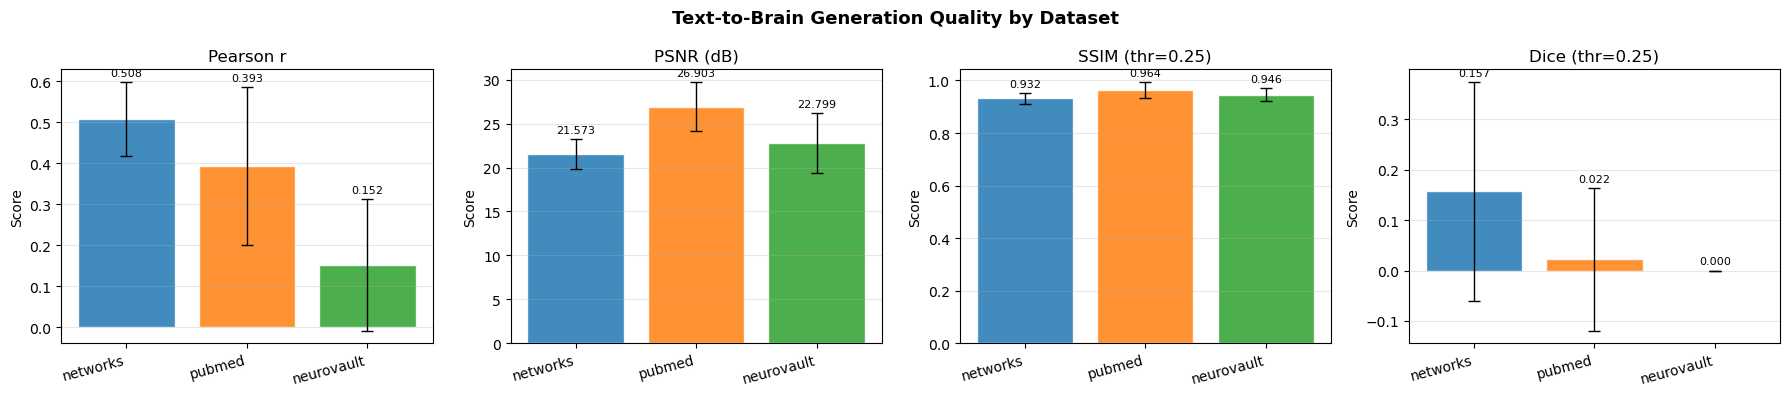

In [19]:
ds_order   = ["networks", "pubmed", "neurovault"]
t2b_cols   = ["pearson_r", "psnr_db", "ssim_t025", "dice_t025"]
t2b_labels = ["Pearson r", "PSNR (dB)", "SSIM (thr=0.25)", "Dice (thr=0.25)"]
ds_colors  = ["C0", "C1", "C2"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
x = np.arange(len(ds_order))

for ax, metric, m_label in zip(axes, t2b_cols, t2b_labels):
    means = [
        t2b_all[t2b_all["dataset"] == ds][metric].mean()
        for ds in ds_order
    ]
    stds = [
        t2b_all[t2b_all["dataset"] == ds][metric].std()
        for ds in ds_order
    ]
    bars = ax.bar(x, means, color=ds_colors, alpha=0.85, edgecolor="white",
                  yerr=stds, capsize=4, error_kw={"linewidth": 1})
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(ds_order, rotation=15, ha="right")
    ax.set_title(m_label)
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Text-to-Brain Generation Quality by Dataset",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("t2b_metrics_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

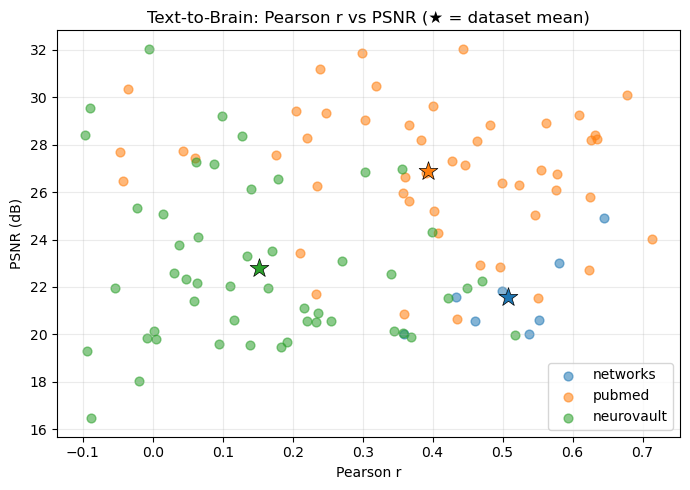

In [20]:
# Pearson r vs PSNR scatter — one point per sample, coloured by dataset
fig, ax = plt.subplots(figsize=(7, 5))

for ds, c in zip(ds_order, ds_colors):
    sub = t2b_all[t2b_all["dataset"] == ds]
    ax.scatter(sub["pearson_r"], sub["psnr_db"],
               s=40, alpha=0.55, color=c, label=ds)
    # Mark mean
    ax.scatter(sub["pearson_r"].mean(), sub["psnr_db"].mean(),
               s=200, color=c, marker="*", zorder=5,
               edgecolors="black", linewidths=0.5)

ax.set_xlabel("Pearson r")
ax.set_ylabel("PSNR (dB)")
ax.set_title("Text-to-Brain: Pearson r vs PSNR (★ = dataset mean)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig("t2b_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Full Evaluation Summary

In [21]:
print("\n" + "="*60)
print("BRAIN-TO-TEXT  (mean across samples)")
print("="*60)
print(
    b2t_all
    .groupby(["dataset", "mode"])[["bleu", "token_f1", "rouge1_f", "rouge2_f", "rougeL_f"]]
    .mean()
    .round(4)
    .to_string()
)

print("\n" + "="*60)
print("TEXT-TO-BRAIN  (spatial metrics mean across samples)")
print("="*60)
print(
    t2b_all
    .groupby("dataset")[["pearson_r", "psnr_db", "ssim_t025", "dice_t025"]]
    .mean()
    .round(4)
    .to_string()
)


BRAIN-TO-TEXT  (mean across samples)
                    bleu  token_f1  rouge1_f  rouge2_f  rougeL_f
dataset    mode                                                 
networks   long   0.0021    0.0523    0.1033    0.0194    0.0750
           short  0.0394    0.2201    0.2805    0.0882    0.2510
neurovault long   0.0037    0.1779    0.2120    0.0174    0.1022
           short  0.0066    0.0436    0.0533    0.0028    0.0403
pubmed     long   0.0044    0.1822    0.2128    0.0209    0.1092
           short  0.0083    0.0726    0.0870    0.0110    0.0715

TEXT-TO-BRAIN  (spatial metrics mean across samples)
            pearson_r  psnr_db  ssim_t025  dice_t025
dataset                                             
networks       0.5084  21.5727     0.9323     0.1570
neurovault     0.1521  22.7990     0.9462     0.0000
pubmed         0.3931  26.9027     0.9636     0.0221
